# Architecture of filters

So, the english is not very good, I will improve that

In [63]:
import itertools

import sympy as sy
import numpy as np

from sympy import Matrix
from sympy.physics.quantum import TensorProduct

In [64]:
import fitz

from utils import plot_pdf, plot_pdf2col, symmetrical_cyclic_convolution, conv_circ_fft

ImportError: cannot import name 'conv_circ_fft' from 'utils' (/home/tarsio/pucrs/gaph/notebooks/utils.py)

In [65]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [66]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

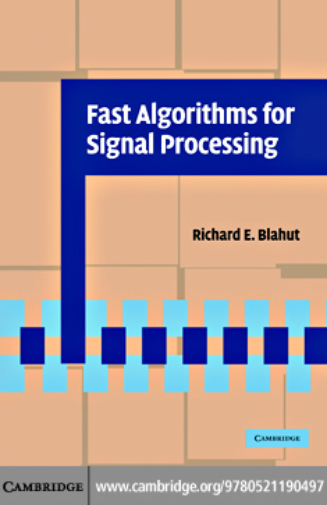

In [67]:
plot_pdf(doc[0], dpi=100)

## Polynomials

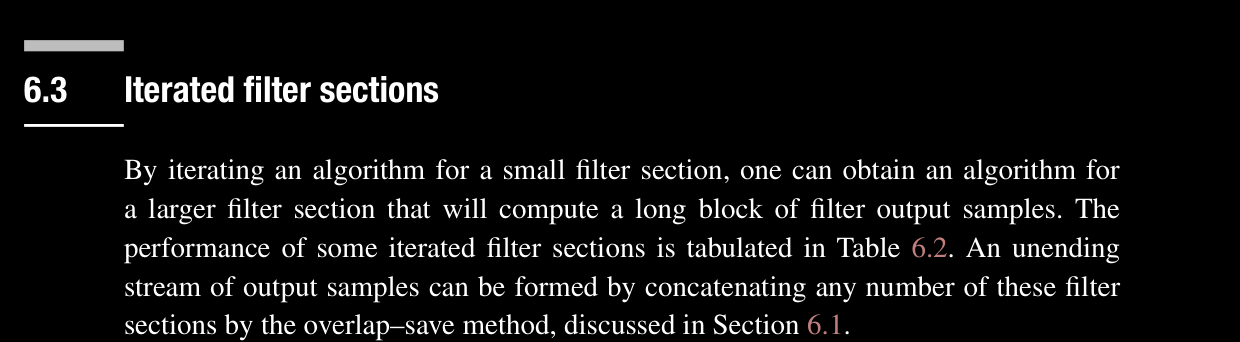

In [68]:
plot_pdf(doc[217], [.6, .78])

Size of vectors

In [69]:
size = 16

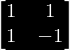

In [70]:
win = sy.Matrix([[1, 1], [1, -1]])
win

In [71]:
d2 = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(size))))
d2.T

In [72]:
g2 = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(size))))
g2.T

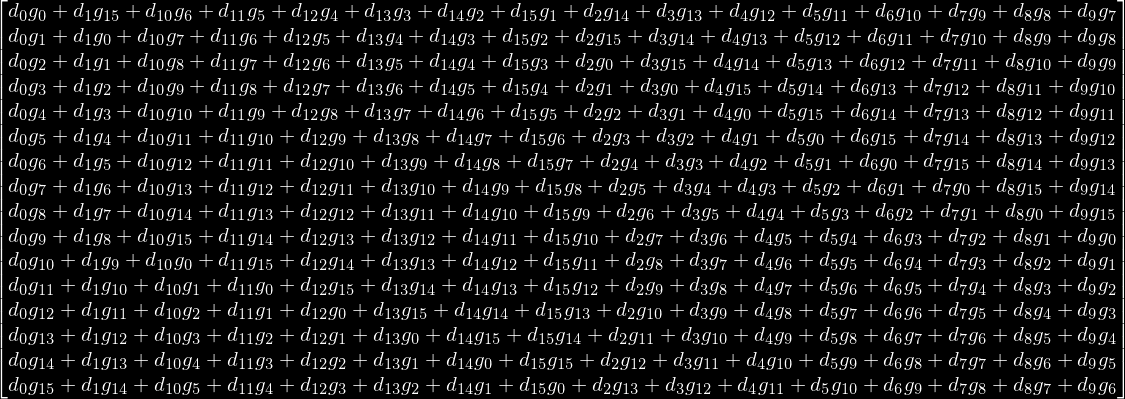

In [73]:
cc2 = sy.Matrix(symmetrical_cyclic_convolution(np.array(d2).reshape(-1), np.array(g2).reshape(-1)))
cc2

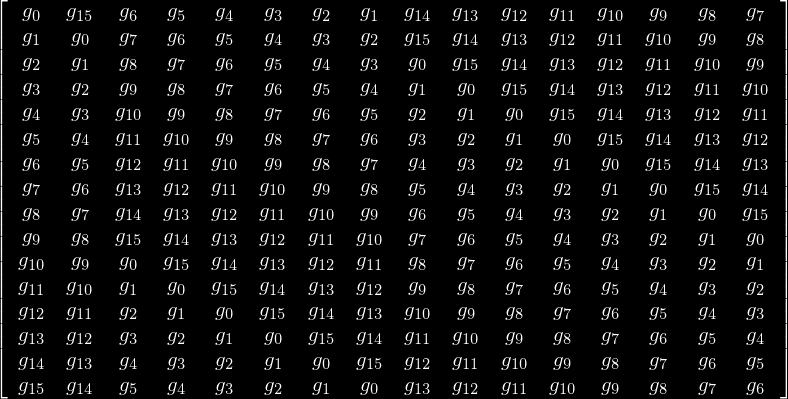

In [74]:
cc2_args = [[arg for mul in line.args for arg in mul.args if 'g' in arg.name] for line in cc2]
sy.Matrix(cc2_args)

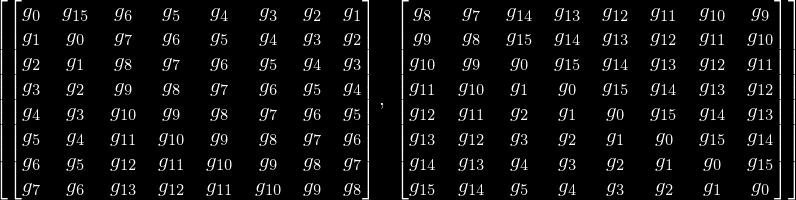

In [75]:
cc2_args = np.array(cc2_args)
g2m = [sy.Matrix(cc2_args[r:r+size//2, c:c+size//2].tolist()) for r in range(0, cc2_args.shape[0], size//2) for c in range(0, cc2_args.shape[1]//2, size//2)]
g2m

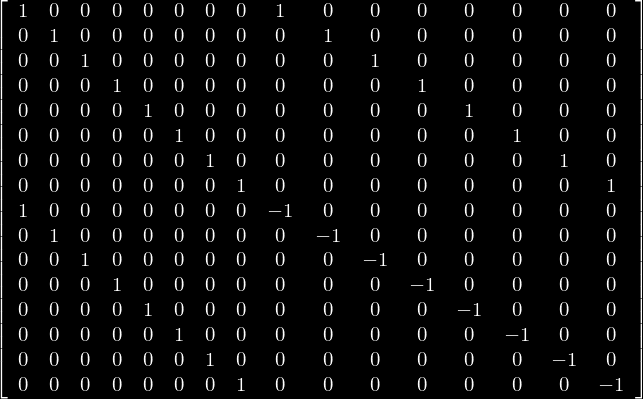

In [76]:
win2 = TensorProduct(win, sy.eye(size//2))
win2

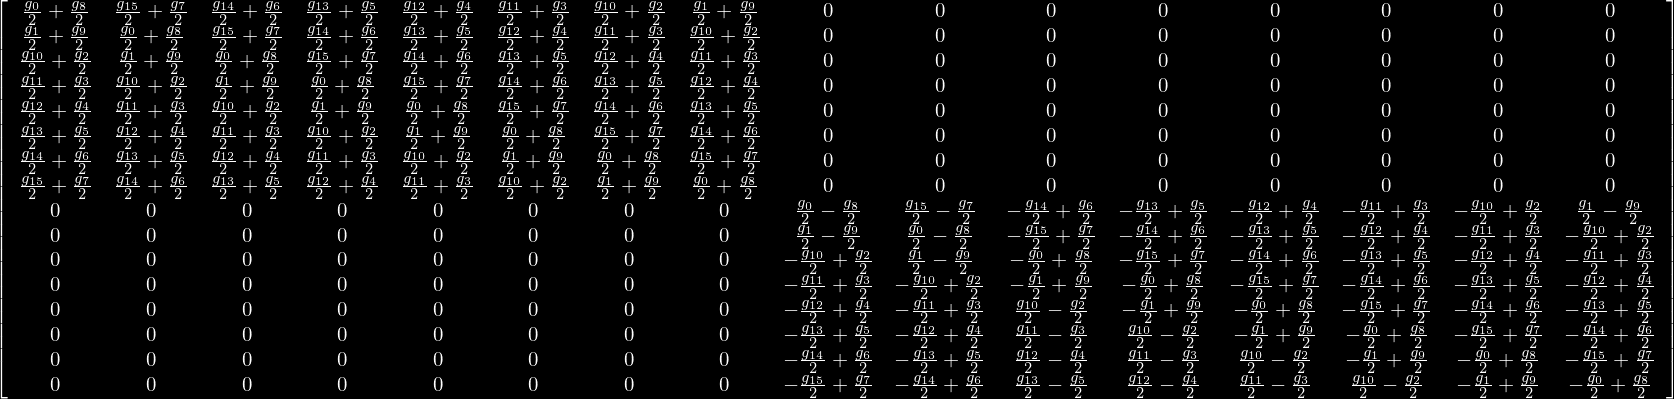

In [77]:
bg2 = sy.diag(*[
    g2m[0] + g2m[1], 
    g2m[0] - g2m[1]
])/2
bg2

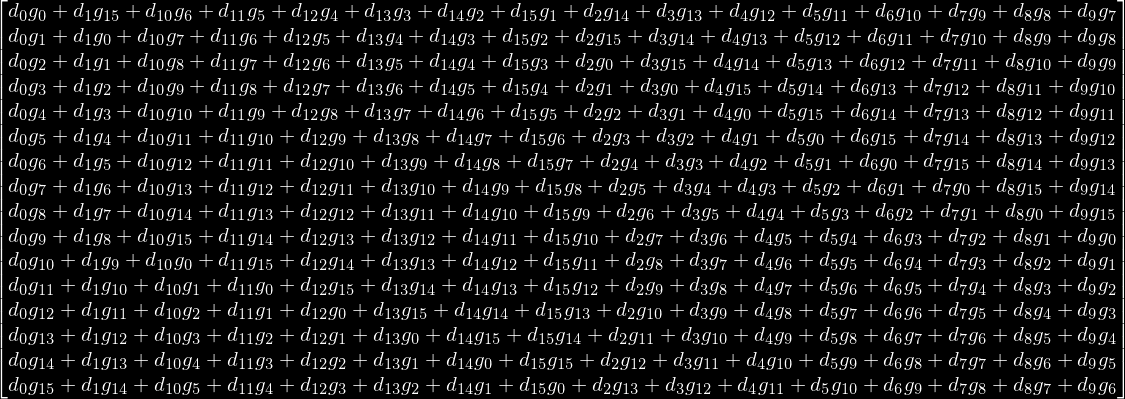

In [78]:
cc = sy.Matrix(symmetrical_cyclic_convolution(np.array(d2).reshape(-1), np.array(g2).reshape(-1)))
cc

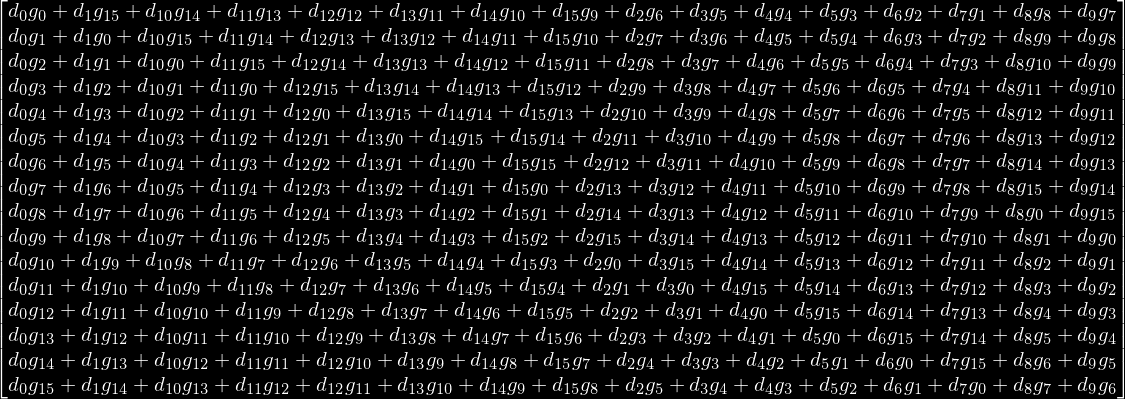

In [79]:
ssx = sy.MatMul(win2, bg2, win2, d2, evaluate=True)
ssx

In [80]:
np.all(np.array(cc) == np.array(ssx))

False

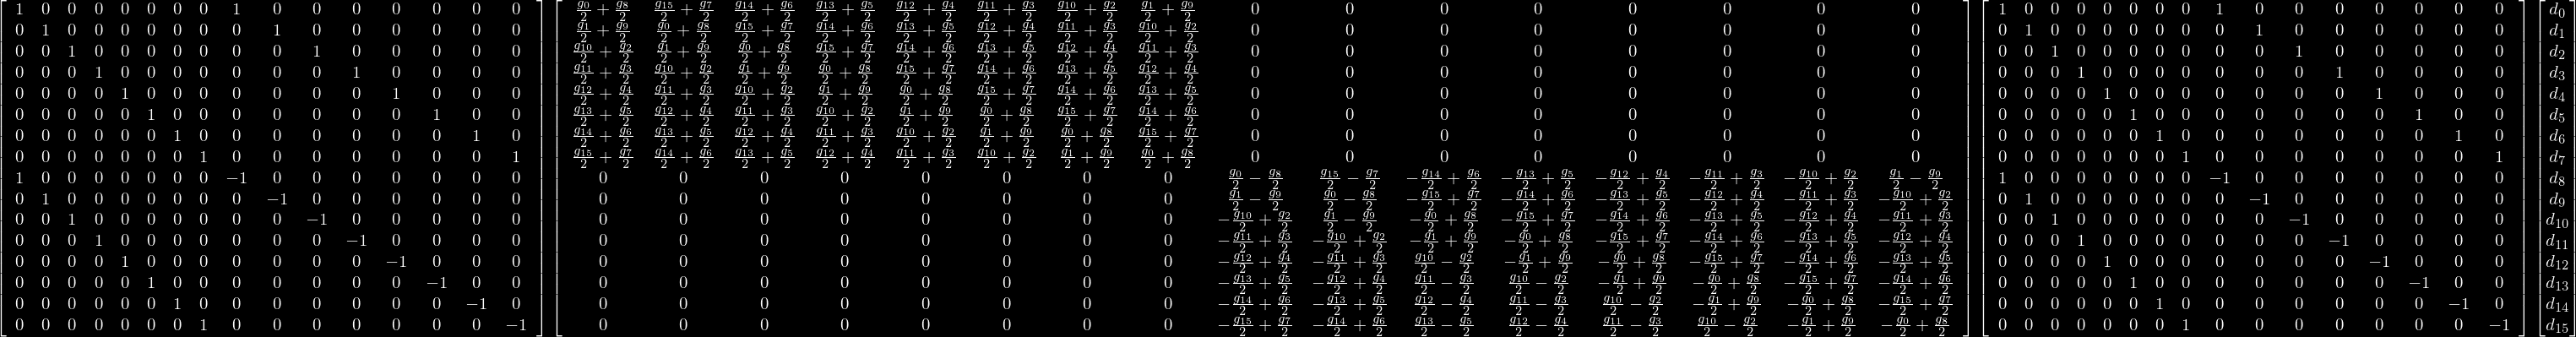

In [81]:
ssx = sy.MatMul(win2, bg2, win2, d2)
ssx

In [82]:
import random
val_d = [random.randint(0, 2**3) for r in range(size)]
val_g = [random.randint(0, 2**3) for r in range(size)]

In [83]:
subs_g = {k: v for k, v in zip(g2.flat(), val_g)}
subs_g

In [84]:
subs_d = {k: v for k, v in zip(g2.flat(), val_d)}
subs_d

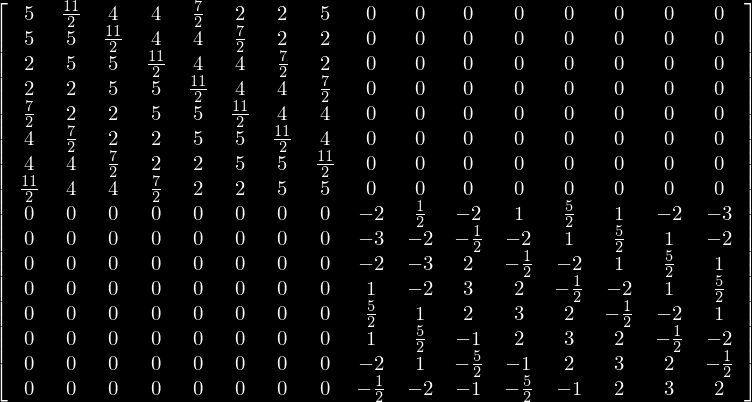

In [85]:
bg2_subs = bg2.subs(subs_g)
bg2_subs

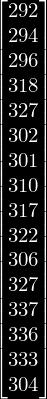

In [86]:
cout = sy.Matrix(symmetrical_cyclic_convolution(val_d, val_g))
cout

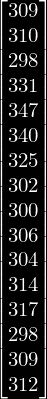

In [87]:
r = win2 * bg2_subs * win2 * sy.Matrix(val_d)
r

In [88]:
np.all(np.array(cout) == np.array(r))

False

Testes como FFT

In [89]:
np.fft.fft(val_d)

array([81.         +0.j        ,  3.19891237-10.32503289j,
       -4.65685425 +6.48528137j,  2.33182136 +3.37048524j,
        5.         +4.j        ,  4.49660576 +1.85576662j,
        6.65685425+10.48528137j, -2.02733949 +8.16024849j,
        1.         +0.j        , -2.02733949 -8.16024849j,
        6.65685425-10.48528137j,  4.49660576 -1.85576662j,
        5.         -4.j        ,  2.33182136 -3.37048524j,
       -4.65685425 -6.48528137j,  3.19891237+10.32503289j])

In [90]:
fft = (np.fft.fft(val_d))
fft.real - fft.imag

array([ 81.        ,  13.52394525, -11.14213562,  -1.03866388,
         1.        ,   2.64083915,  -3.82842712, -10.18758798,
         1.        ,   6.13290899,  17.14213562,   6.35237238,
         9.        ,   5.7023066 ,   1.82842712,  -7.12612052])

In [91]:
fft.real + fft.imag

array([ 81.        ,  -7.12612052,   1.82842712,   5.7023066 ,
         9.        ,   6.35237238,  17.14213562,   6.13290899,
         1.        , -10.18758798,  -3.82842712,   2.64083915,
         1.        ,  -1.03866388, -11.14213562,  13.52394525])

Se eu meter um número imaginário $i$ em alguns lugares oq será q acontece? 

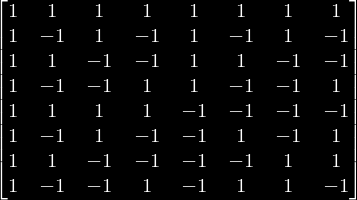

In [92]:
winft = TensorProduct(win, win, win)
winft

In [93]:
winft * sy.Matrix(val_d)

ShapeError: Matrix size mismatch: (8, 8) * (16, 1).

In [94]:
np.fft.fft([3,10])

array([13.+0.j, -7.+0.j])

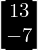

In [95]:
win * sy.Matrix([3, 10])